In [1]:
from pathlib import Path
import pandas as pd
import numpy as np

# Project root
PROJECT_ROOT = Path.cwd().parent

# Load cleaned data
DATA_PATH = PROJECT_ROOT / "data" / "processed" / "cleaned_survey.csv"

df = pd.read_csv(DATA_PATH)

print("=" * 60)
print("AWARENESS PREDICTION MODEL")
print("=" * 60)

print(f"Dataset shape: {df.shape}")

print("\nTarget distribution:")
print(df["outlook_awareness_1"].value_counts())

print("\nTarget percentage:")
print(
    df["outlook_awareness_1"]
    .value_counts(normalize=True)
    .mul(100)
    .round(2)
)

AWARENESS PREDICTION MODEL
Dataset shape: (11109, 101)

Target distribution:
outlook_awareness_1
No     5623
Yes    5486
Name: count, dtype: int64

Target percentage:
outlook_awareness_1
No     50.62
Yes    49.38
Name: proportion, dtype: float64


In [2]:
# ---------------------------------------------------------
# STAGE 8A: SELECT MODEL FEATURES
# ---------------------------------------------------------

target = "outlook_awareness_1"

features = [
    "age_group",
    "gender",
    "education_level",
    "residence_type",
    "employment_status",
    "brand_discovery_method",
    "brand_awareness_driver",
    "digital_ad_platform",
    "digital_campaign_frequency",
    "digital_purchase_frequency",
    "digital_monthly_spend",
    "previous_purchase"
]

# Keep only required columns
model_df = df[features + [target]].copy()

print("=" * 60)
print("MODEL DATASET")
print("=" * 60)

print(f"Rows    : {model_df.shape[0]:,}")
print(f"Columns : {model_df.shape[1]}")

print("\nFeatures:")
for feature in features:
    print(f"- {feature}")

print(f"\nTarget:\n- {target}")

MODEL DATASET
Rows    : 11,109
Columns : 13

Features:
- age_group
- gender
- education_level
- residence_type
- employment_status
- brand_discovery_method
- brand_awareness_driver
- digital_ad_platform
- digital_campaign_frequency
- digital_purchase_frequency
- digital_monthly_spend
- previous_purchase

Target:
- outlook_awareness_1


In [3]:
# Check missing values before modeling

missing = model_df.isnull().sum()

print("Missing values:")
print(missing[missing > 0])

if missing.sum() == 0:
    print("\n✓ No missing values in modeling dataset.")
else:
    print("\n⚠ Missing values found. We will handle them before modeling.")

Missing values:
Series([], dtype: int64)

✓ No missing values in modeling dataset.


In [4]:
# ---------------------------------------------------------
# STAGE 8B: ENCODE TARGET
# ---------------------------------------------------------

model_df["awareness_target"] = (
    model_df["outlook_awareness_1"]
    .str.strip()
    .str.lower()
    .map({
        "no": 0,
        "yes": 1
    })
)

# Check whether every value was successfully mapped
print("Encoded target distribution:")
print(model_df["awareness_target"].value_counts(dropna=False))

print("\nTarget percentages:")
print(
    model_df["awareness_target"]
    .value_counts(normalize=True)
    .mul(100)
    .round(2)
)

# Safety check
if model_df["awareness_target"].isna().sum() > 0:
    raise ValueError(
        "Some target values could not be encoded. "
        "Check the original outlook_awareness_1 values."
    )

print("\n✓ Target successfully encoded.")

Encoded target distribution:
awareness_target
0    5623
1    5486
Name: count, dtype: int64

Target percentages:
awareness_target
0    50.62
1    49.38
Name: proportion, dtype: float64

✓ Target successfully encoded.


In [5]:
# ---------------------------------------------------------
# STAGE 8C: TRAIN / TEST SPLIT
# ---------------------------------------------------------

from sklearn.model_selection import train_test_split

# X = predictor variables
X = model_df[features].copy()

# y = target variable
y = model_df["awareness_target"].copy()

# 80% training, 20% testing
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("=" * 60)
print("TRAIN / TEST SPLIT")
print("=" * 60)

print(f"Total observations : {len(X):,}")
print(f"Training set       : {len(X_train):,}")
print(f"Test set           : {len(X_test):,}")

print("\nTraining target distribution:")
print(
    y_train.value_counts(normalize=True)
    .mul(100)
    .round(2)
)

print("\nTest target distribution:")
print(
    y_test.value_counts(normalize=True)
    .mul(100)
    .round(2)
)

TRAIN / TEST SPLIT
Total observations : 11,109
Training set       : 8,887
Test set           : 2,222

Training target distribution:
awareness_target
0    50.61
1    49.39
Name: proportion, dtype: float64

Test target distribution:
awareness_target
0    50.63
1    49.37
Name: proportion, dtype: float64


In [6]:
# ---------------------------------------------------------
# STAGE 8D: IDENTIFY NUMERIC AND CATEGORICAL FEATURES
# ---------------------------------------------------------

numeric_features = X_train.select_dtypes(
    include=["int64", "float64"]
).columns.tolist()

categorical_features = X_train.select_dtypes(
    include=["object", "category", "bool"]
).columns.tolist()

print("Numeric features:")
for col in numeric_features:
    print(f"- {col}")

print("\nCategorical features:")
for col in categorical_features:
    print(f"- {col}")

print("\nFeature count:")
print(f"Numeric      : {len(numeric_features)}")
print(f"Categorical  : {len(categorical_features)}")
print(f"Total        : {len(numeric_features) + len(categorical_features)}")

Numeric features:

Categorical features:
- age_group
- gender
- education_level
- residence_type
- employment_status
- brand_discovery_method
- brand_awareness_driver
- digital_ad_platform
- digital_campaign_frequency
- digital_purchase_frequency
- digital_monthly_spend
- previous_purchase

Feature count:
Numeric      : 0
Categorical  : 12
Total        : 12


C:\Users\DIVYANSHU KASHYAP\AppData\Local\Temp\ipykernel_26484\3658828772.py:9: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  categorical_features = X_train.select_dtypes(


In [7]:
# ---------------------------------------------------------
# STAGE 8D: CREATE PREPROCESSING PIPELINE
# ---------------------------------------------------------

from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder

preprocessor = ColumnTransformer(
    transformers=[
        (
            "categorical",
            OneHotEncoder(
                handle_unknown="ignore",
                drop="first"
            ),
            categorical_features
        ),
        (
            "numeric",
            "passthrough",
            numeric_features
        )
    ]
)

print("✓ Preprocessing pipeline created.")

✓ Preprocessing pipeline created.


In [8]:
# ---------------------------------------------------------
# STAGE 8E: LOGISTIC REGRESSION
# ---------------------------------------------------------

from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression

# Create the complete modeling pipeline
logistic_model = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        (
            "classifier",
            LogisticRegression(
                max_iter=1000,
                random_state=42
            )
        )
    ]
)

# Train the model
logistic_model.fit(X_train, y_train)

print("✓ Logistic Regression model trained successfully.")


✓ Logistic Regression model trained successfully.


In [9]:
# ---------------------------------------------------------
# STAGE 8F: MODEL EVALUATION
# ---------------------------------------------------------

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    classification_report
)

# Predictions
y_pred = logistic_model.predict(X_test)

# Probability of being aware
y_prob = logistic_model.predict_proba(X_test)[:, 1]

# Calculate metrics
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)
roc_auc = roc_auc_score(y_test, y_prob)

print("=" * 60)
print("LOGISTIC REGRESSION PERFORMANCE")
print("=" * 60)

print(f"Accuracy  : {accuracy:.4f}")
print(f"Precision : {precision:.4f}")
print(f"Recall    : {recall:.4f}")
print(f"F1 Score  : {f1:.4f}")
print(f"ROC-AUC   : {roc_auc:.4f}")

print("\nClassification Report:")
print(
    classification_report(
        y_test,
        y_pred,
        target_names=["Not Aware", "Aware"]
    )
)

print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred))

LOGISTIC REGRESSION PERFORMANCE
Accuracy  : 0.5000
Precision : 0.4925
Recall    : 0.4184
F1 Score  : 0.4524
ROC-AUC   : 0.4976

Classification Report:
              precision    recall  f1-score   support

   Not Aware       0.51      0.58      0.54      1125
       Aware       0.49      0.42      0.45      1097

    accuracy                           0.50      2222
   macro avg       0.50      0.50      0.50      2222
weighted avg       0.50      0.50      0.50      2222


Confusion Matrix:
[[652 473]
 [638 459]]


In [10]:
# ---------------------------------------------------------
# STAGE 8G: SAVE MODEL PERFORMANCE
# ---------------------------------------------------------

from pathlib import Path

OUTPUT_DIR = PROJECT_ROOT / "outputs" / "tables"
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

model_results = pd.DataFrame({
    "model": ["Logistic Regression"],
    "accuracy": [accuracy],
    "precision": [precision],
    "recall": [recall],
    "f1_score": [f1],
    "roc_auc": [roc_auc]
})

results_path = OUTPUT_DIR / "awareness_model_results.csv"

model_results.to_csv(results_path, index=False)

print(f"✓ Model results saved to:")
print(results_path)

✓ Model results saved to:
c:\Users\DIVYANSHU KASHYAP\Desktop\OUTLOOK-CUSTOMER-INTELLIGENCE\outputs\tables\awareness_model_results.csv


In [11]:
# ---------------------------------------------------------
# STAGE 8H: LOGISTIC REGRESSION COEFFICIENTS
# ---------------------------------------------------------

# Get the fitted preprocessing step
fitted_preprocessor = logistic_model.named_steps["preprocessor"]

# Get the fitted logistic regression classifier
classifier = logistic_model.named_steps["classifier"]

# Get the names of the transformed features
feature_names = fitted_preprocessor.get_feature_names_out()

# Get model coefficients
coefficients = classifier.coef_[0]

# Create coefficient table
coefficient_table = pd.DataFrame({
    "feature": feature_names,
    "coefficient": coefficients,
    "odds_ratio": np.exp(coefficients)
})

# Add absolute coefficient for sorting
coefficient_table["abs_coefficient"] = (
    coefficient_table["coefficient"].abs()
)

# Sort by absolute importance
coefficient_table = coefficient_table.sort_values(
    "abs_coefficient",
    ascending=False
)

print("=" * 60)
print("LOGISTIC REGRESSION COEFFICIENTS")
print("=" * 60)

print(
    coefficient_table[
        ["feature", "coefficient", "odds_ratio"]
    ].to_string(index=False)
)

LOGISTIC REGRESSION COEFFICIENTS
                                                          feature  coefficient  odds_ratio
                          categorical__digital_ad_platform_Google     0.229702    1.258225
                   categorical__digital_purchase_frequency_Weekly     0.172688    1.188495
                          categorical__digital_ad_platform_Reddit     0.159602    1.173043
                       categorical__brand_discovery_method_Others    -0.155053    0.856370
                         categorical__digital_ad_platform_Twitter     0.150193    1.162058
                        categorical__digital_ad_platform_Facebook     0.149339    1.161067
    categorical__brand_discovery_method_People who I know read it    -0.141969    0.867648
                          categorical__digital_ad_platform_Tumblr     0.140204    1.150508
                         categorical__digital_ad_platform_Spotify     0.136212    1.145925
                  categorical__digital_purchase_frequency

In [12]:
# ---------------------------------------------------------
# STAGE 8H: BUSINESS-FRIENDLY COEFFICIENT TABLE
# ---------------------------------------------------------

interpretation_table = coefficient_table[
    ["feature", "coefficient", "odds_ratio"]
].copy()

interpretation_table["direction"] = np.where(
    interpretation_table["odds_ratio"] > 1,
    "Higher awareness odds",
    "Lower awareness odds"
)

interpretation_table["odds_change_percent"] = (
    (interpretation_table["odds_ratio"] - 1) * 100
).round(2)

interpretation_table = interpretation_table[
    [
        "feature",
        "coefficient",
        "odds_ratio",
        "direction",
        "odds_change_percent"
    ]
]

print(
    interpretation_table.to_string(index=False)
)

                                                          feature  coefficient  odds_ratio             direction  odds_change_percent
                          categorical__digital_ad_platform_Google     0.229702    1.258225 Higher awareness odds                25.82
                   categorical__digital_purchase_frequency_Weekly     0.172688    1.188495 Higher awareness odds                18.85
                          categorical__digital_ad_platform_Reddit     0.159602    1.173043 Higher awareness odds                17.30
                       categorical__brand_discovery_method_Others    -0.155053    0.856370  Lower awareness odds               -14.36
                         categorical__digital_ad_platform_Twitter     0.150193    1.162058 Higher awareness odds                16.21
                        categorical__digital_ad_platform_Facebook     0.149339    1.161067 Higher awareness odds                16.11
    categorical__brand_discovery_method_People who I know read

In [13]:
# ---------------------------------------------------------
# STAGE 8I: PREPARE DATA FOR STATISTICAL INFERENCE
# ---------------------------------------------------------

import statsmodels.api as sm

# Transform the data using the already-fitted preprocessor
X_train_encoded = fitted_preprocessor.transform(X_train)
X_test_encoded = fitted_preprocessor.transform(X_test)

# Convert sparse matrices to dense arrays if necessary
if hasattr(X_train_encoded, "toarray"):
    X_train_encoded = X_train_encoded.toarray()

if hasattr(X_test_encoded, "toarray"):
    X_test_encoded = X_test_encoded.toarray()

print("Training matrix shape:", X_train_encoded.shape)
print("Test matrix shape:", X_test_encoded.shape)

Training matrix shape: (8887, 42)
Test matrix shape: (2222, 42)


In [14]:
# ---------------------------------------------------------
# STAGE 8I: LOGISTIC REGRESSION INFERENCE
# ---------------------------------------------------------

# Add intercept
X_train_sm = sm.add_constant(
    X_train_encoded,
    has_constant="add"
)

# Fit logistic regression
stats_model = sm.Logit(
    y_train,
    X_train_sm
)

stats_result = stats_model.fit(
    disp=False,
    maxiter=1000
)

print(stats_result.summary())

                           Logit Regression Results                           
Dep. Variable:       awareness_target   No. Observations:                 8887
Model:                          Logit   Df Residuals:                     8844
Method:                           MLE   Df Model:                           42
Date:                Fri, 04 Sep 2026   Pseudo R-squ.:                0.003385
Time:                        03:35:49   Log-Likelihood:                -6138.5
converged:                       True   LL-Null:                       -6159.3
Covariance Type:            nonrobust   LLR p-value:                    0.4843
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const         -0.1249      0.140     -0.894      0.371      -0.399       0.149
x1            -0.0166      0.061     -0.274      0.784      -0.135       0.102
x2            -0.0048      0.061     -0.079      0.9

In [15]:
# ---------------------------------------------------------
# STAGE 8I: CREATE INFERENCE TABLE
# ---------------------------------------------------------

inference_table = pd.DataFrame({
    "feature": ["Intercept"] + list(feature_names),
    "coefficient": stats_result.params,
    "std_error": stats_result.bse,
    "p_value": stats_result.pvalues,
    "odds_ratio": np.exp(stats_result.params),
    "ci_lower": np.exp(stats_result.conf_int()[0]),
    "ci_upper": np.exp(stats_result.conf_int()[1])
})

inference_table["significant_0_05"] = (
    inference_table["p_value"] < 0.05
)

inference_table = inference_table.sort_values(
    "p_value"
)

print(
    inference_table.to_string(index=False)
)

                                                          feature  coefficient  std_error  p_value  odds_ratio  ci_lower  ci_upper  significant_0_05
                   categorical__digital_purchase_frequency_Weekly     0.175416   0.067132 0.008975    1.191742  1.044815  1.359330              True
                       categorical__brand_discovery_method_Others    -0.155237   0.067108 0.020709    0.856212  0.750687  0.976571              True
                          categorical__digital_ad_platform_Google     0.236842   0.104703 0.023695    1.267241  1.032134  1.555902              True
    categorical__brand_discovery_method_People who I know read it    -0.142487   0.066726 0.032727    0.867199  0.760890  0.988361              True
                  categorical__digital_purchase_frequency_Monthly     0.137105   0.067342 0.041755    1.146949  1.005131  1.308778              True
                     categorical__employment_status_Self Employed     0.108351   0.059931 0.070619    1.11

In [16]:
# ---------------------------------------------------------
# STAGE 8J: MULTIPLE-TESTING CORRECTION
# ---------------------------------------------------------

from statsmodels.stats.multitest import multipletests

# Exclude intercept from multiple-testing correction
predictor_mask = inference_table["feature"] != "Intercept"

p_values = inference_table.loc[
    predictor_mask, "p_value"
]

# Holm correction
reject, p_adjusted, _, _ = multipletests(
    p_values,
    alpha=0.05,
    method="holm"
)

# Add corrected results
inference_table.loc[
    predictor_mask, "holm_p_value"
] = p_adjusted

inference_table.loc[
    predictor_mask, "significant_after_holm"
] = reject

# Intercept doesn't need correction
inference_table.loc[
    ~predictor_mask, "holm_p_value"
] = np.nan

inference_table.loc[
    ~predictor_mask, "significant_after_holm"
] = False

print("=" * 60)
print("HOLM-CORRECTED LOGISTIC REGRESSION")
print("=" * 60)

display(
    inference_table[
        [
            "feature",
            "coefficient",
            "odds_ratio",
            "p_value",
            "holm_p_value",
            "ci_lower",
            "ci_upper",
            "significant_after_holm"
        ]
    ]
)

HOLM-CORRECTED LOGISTIC REGRESSION


,feature,coefficient,odds_ratio,p_value,holm_p_value,ci_lower,ci_upper,significant_after_holm
x35,categorical__digital_purchase_frequency_Weekly,0.175416,1.191742,0.008975,0.376950,1.044815,1.359330,False
x12,categorical__brand_discovery_method_Others,-0.155237,0.856212,0.020709,0.849086,0.750687,0.976571,False
x20,categorical__digital_ad_platform_Google,0.236842,1.267241,0.023695,0.947787,1.032134,1.555902,False
x13,categorical__brand_discovery_method_People who...,-0.142487,0.867199,0.032727,1.000000,0.760890,0.988361,False
x33,categorical__digital_purchase_frequency_Monthly,0.137105,1.146949,0.041755,1.000000,1.005131,1.308778,False
x9,categorical__employment_status_Self Employed,0.108351,1.114438,0.070619,1.000000,0.990929,1.253342,False
x25,categorical__digital_ad_platform_Reddit,0.167214,1.182008,0.106189,1.000000,0.964981,1.447844,False
x28,categorical__digital_ad_platform_Twitter,0.158121,1.171308,0.131840,1.000000,0.953570,1.438764,False
x19,categorical__digital_ad_platform_Facebook,0.157060,1.170066,0.141171,1.000000,0.949192,1.442335,False
x42,categorical__previous_purchase_Sometimes,-0.076679,0.926187,0.143246,1.000000,0.835814,1.026331,False


In [17]:
# ---------------------------------------------------------
# STAGE 8K: SAVE INFERENCE RESULTS
# ---------------------------------------------------------

inference_path = (
    PROJECT_ROOT
    / "outputs"
    / "tables"
    / "awareness_logistic_inference.csv"
)

inference_table.to_csv(
    inference_path,
    index=False
)

print("✓ Logistic regression inference results saved:")
print(inference_path)

✓ Logistic regression inference results saved:
c:\Users\DIVYANSHU KASHYAP\Desktop\OUTLOOK-CUSTOMER-INTELLIGENCE\outputs\tables\awareness_logistic_inference.csv


In [18]:
# ---------------------------------------------------------
# STAGE 8L: 5-FOLD STRATIFIED CROSS-VALIDATION
# ---------------------------------------------------------

from sklearn.model_selection import StratifiedKFold, cross_validate

cv = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

cv_results = cross_validate(
    logistic_model,
    X,
    y,
    cv=cv,
    scoring=[
        "accuracy",
        "precision",
        "recall",
        "f1",
        "roc_auc"
    ],
    n_jobs=-1
)

cv_summary = pd.DataFrame({
    "metric": [
        "accuracy",
        "precision",
        "recall",
        "f1",
        "roc_auc"
    ],
    "mean": [
        cv_results["test_accuracy"].mean(),
        cv_results["test_precision"].mean(),
        cv_results["test_recall"].mean(),
        cv_results["test_f1"].mean(),
        cv_results["test_roc_auc"].mean()
    ],
    "std": [
        cv_results["test_accuracy"].std(),
        cv_results["test_precision"].std(),
        cv_results["test_recall"].std(),
        cv_results["test_f1"].std(),
        cv_results["test_roc_auc"].std()
    ]
})

print("=" * 60)
print("5-FOLD CROSS-VALIDATION")
print("=" * 60)

display(
    cv_summary.round(4)
)

5-FOLD CROSS-VALIDATION


,metric,mean,std
0,accuracy,0.5058,0.0068
1,precision,0.4995,0.0081
2,recall,0.4316,0.0169
3,f1,0.4630,0.0120
4,roc_auc,0.5064,0.0066


In [19]:
# ---------------------------------------------------------
# STAGE 8L: SAVE CROSS-VALIDATION RESULTS
# ---------------------------------------------------------

cv_path = (
    PROJECT_ROOT
    / "outputs"
    / "tables"
    / "awareness_logistic_cross_validation.csv"
)

cv_summary.to_csv(
    cv_path,
    index=False
)

print("✓ Cross-validation results saved:")
print(cv_path)

✓ Cross-validation results saved:
c:\Users\DIVYANSHU KASHYAP\Desktop\OUTLOOK-CUSTOMER-INTELLIGENCE\outputs\tables\awareness_logistic_cross_validation.csv


In [20]:
# ---------------------------------------------------------
# STAGE 8M: BASELINE COMPARISON
# ---------------------------------------------------------

from sklearn.dummy import DummyClassifier

# Majority-class baseline
baseline_model = DummyClassifier(
    strategy="most_frequent"
)

baseline_model.fit(X_train, y_train)

baseline_pred = baseline_model.predict(X_test)

baseline_accuracy = accuracy_score(
    y_test,
    baseline_pred
)

baseline_f1 = f1_score(
    y_test,
    baseline_pred,
    zero_division=0
)

baseline_results = pd.DataFrame({
    "model": [
        "Majority Class Baseline",
        "Logistic Regression"
    ],
    "accuracy": [
        baseline_accuracy,
        accuracy
    ],
    "f1_score": [
        baseline_f1,
        f1
    ],
    "roc_auc": [
        0.50,
        roc_auc
    ]
})

print("=" * 60)
print("BASELINE VS LOGISTIC REGRESSION")
print("=" * 60)

display(
    baseline_results.round(4)
)

BASELINE VS LOGISTIC REGRESSION


,model,accuracy,f1_score,roc_auc
0,Majority Class Baseline,0.5063,0.0000,0.5000
1,Logistic Regression,0.5000,0.4524,0.4976


In [21]:
# ---------------------------------------------------------
# SAVE BASELINE COMPARISON
# ---------------------------------------------------------

baseline_path = (
    PROJECT_ROOT
    / "outputs"
    / "tables"
    / "awareness_baseline_comparison.csv"
)

baseline_results.to_csv(
    baseline_path,
    index=False
)

print("✓ Baseline comparison saved:")
print(baseline_path)

✓ Baseline comparison saved:
c:\Users\DIVYANSHU KASHYAP\Desktop\OUTLOOK-CUSTOMER-INTELLIGENCE\outputs\tables\awareness_baseline_comparison.csv


In [22]:
# ---------------------------------------------------------
# STAGE 9A: DECISION TREE
# ---------------------------------------------------------

from sklearn.tree import DecisionTreeClassifier

decision_tree_model = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        (
            "classifier",
            DecisionTreeClassifier(
                max_depth=5,
                min_samples_leaf=20,
                random_state=42
            )
        )
    ]
)

# Train
decision_tree_model.fit(X_train, y_train)

# Predictions
tree_pred = decision_tree_model.predict(X_test)
tree_prob = decision_tree_model.predict_proba(X_test)[:, 1]

# Metrics
tree_accuracy = accuracy_score(y_test, tree_pred)
tree_precision = precision_score(
    y_test,
    tree_pred,
    zero_division=0
)
tree_recall = recall_score(
    y_test,
    tree_pred,
    zero_division=0
)
tree_f1 = f1_score(
    y_test,
    tree_pred,
    zero_division=0
)
tree_auc = roc_auc_score(y_test, tree_prob)

print("=" * 60)
print("DECISION TREE PERFORMANCE")
print("=" * 60)

print(f"Accuracy  : {tree_accuracy:.4f}")
print(f"Precision : {tree_precision:.4f}")
print(f"Recall    : {tree_recall:.4f}")
print(f"F1 Score  : {tree_f1:.4f}")
print(f"ROC-AUC   : {tree_auc:.4f}")

DECISION TREE PERFORMANCE
Accuracy  : 0.5059
Precision : 0.4993
Recall    : 0.3318
F1 Score  : 0.3987
ROC-AUC   : 0.5077


In [23]:
# ---------------------------------------------------------
# STAGE 9B: RANDOM FOREST
# ---------------------------------------------------------

from sklearn.ensemble import RandomForestClassifier

random_forest_model = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        (
            "classifier",
            RandomForestClassifier(
                n_estimators=300,
                max_depth=8,
                min_samples_leaf=10,
                random_state=42,
                n_jobs=-1
            )
        )
    ]
)

# Train
random_forest_model.fit(X_train, y_train)

# Predictions
rf_pred = random_forest_model.predict(X_test)
rf_prob = random_forest_model.predict_proba(X_test)[:, 1]

# Metrics
rf_accuracy = accuracy_score(y_test, rf_pred)
rf_precision = precision_score(
    y_test,
    rf_pred,
    zero_division=0
)
rf_recall = recall_score(
    y_test,
    rf_pred,
    zero_division=0
)
rf_f1 = f1_score(
    y_test,
    rf_pred,
    zero_division=0
)
rf_auc = roc_auc_score(y_test, rf_prob)

print("=" * 60)
print("RANDOM FOREST PERFORMANCE")
print("=" * 60)

print(f"Accuracy  : {rf_accuracy:.4f}")
print(f"Precision : {rf_precision:.4f}")
print(f"Recall    : {rf_recall:.4f}")
print(f"F1 Score  : {rf_f1:.4f}")
print(f"ROC-AUC   : {rf_auc:.4f}")

RANDOM FOREST PERFORMANCE
Accuracy  : 0.5018
Precision : 0.4945
Recall    : 0.4093
F1 Score  : 0.4479
ROC-AUC   : 0.4991


In [24]:
# ---------------------------------------------------------
# STAGE 9C: MODEL COMPARISON
# ---------------------------------------------------------

model_comparison = pd.DataFrame({
    "model": [
        "Majority Class Baseline",
        "Logistic Regression",
        "Decision Tree",
        "Random Forest"
    ],
    "accuracy": [
        baseline_accuracy,
        accuracy,
        tree_accuracy,
        rf_accuracy
    ],
    "precision": [
        np.nan,
        precision,
        tree_precision,
        rf_precision
    ],
    "recall": [
        np.nan,
        recall,
        tree_recall,
        rf_recall
    ],
    "f1_score": [
        baseline_f1,
        f1,
        tree_f1,
        rf_f1
    ],
    "roc_auc": [
        0.50,
        roc_auc,
        tree_auc,
        rf_auc
    ]
})

print("=" * 60)
print("AWARENESS MODEL COMPARISON")
print("=" * 60)

display(
    model_comparison.round(4)
)

AWARENESS MODEL COMPARISON


,model,accuracy,precision,recall,f1_score,roc_auc
0,Majority Class Baseline,0.5063,NaN,NaN,0.0000,0.5000
1,Logistic Regression,0.5000,0.4925,0.4184,0.4524,0.4976
2,Decision Tree,0.5059,0.4993,0.3318,0.3987,0.5077
3,Random Forest,0.5018,0.4945,0.4093,0.4479,0.4991


In [25]:
# ---------------------------------------------------------
# STAGE 9D: CROSS-VALIDATE ALL MODELS
# ---------------------------------------------------------

models = {
    "Logistic Regression": logistic_model,
    "Decision Tree": decision_tree_model,
    "Random Forest": random_forest_model
}

cv_model_results = []

for model_name, model in models.items():

    scores = cross_validate(
        model,
        X,
        y,
        cv=cv,
        scoring=[
            "accuracy",
            "precision",
            "recall",
            "f1",
            "roc_auc"
        ],
        n_jobs=-1
    )

    cv_model_results.append({
        "model": model_name,
        "accuracy_mean": scores["test_accuracy"].mean(),
        "accuracy_std": scores["test_accuracy"].std(),
        "precision_mean": scores["test_precision"].mean(),
        "recall_mean": scores["test_recall"].mean(),
        "f1_mean": scores["test_f1"].mean(),
        "roc_auc_mean": scores["test_roc_auc"].mean(),
        "roc_auc_std": scores["test_roc_auc"].std()
    })

cv_model_comparison = pd.DataFrame(cv_model_results)

print("=" * 60)
print("5-FOLD CROSS-VALIDATED MODEL COMPARISON")
print("=" * 60)

display(
    cv_model_comparison.round(4)
)

5-FOLD CROSS-VALIDATED MODEL COMPARISON


,model,accuracy_mean,accuracy_std,precision_mean,recall_mean,f1_mean,roc_auc_mean,roc_auc_std
0,Logistic Regression,0.5058,0.0068,0.4995,0.4316,0.4630,0.5064,0.0066
1,Decision Tree,0.4967,0.0072,0.4857,0.3551,0.4037,0.4908,0.0095
2,Random Forest,0.5087,0.0048,0.5034,0.3875,0.4378,0.5058,0.0083


In [26]:
# ---------------------------------------------------------
# STAGE 9E: SAVE MODEL COMPARISON
# ---------------------------------------------------------

model_comparison_path = (
    PROJECT_ROOT
    / "outputs"
    / "tables"
    / "awareness_model_comparison.csv"
)

model_comparison.to_csv(
    model_comparison_path,
    index=False
)

cv_comparison_path = (
    PROJECT_ROOT
    / "outputs"
    / "tables"
    / "awareness_model_cv_comparison.csv"
)

cv_model_comparison.to_csv(
    cv_comparison_path,
    index=False
)

print("✓ Test-set comparison saved:")
print(model_comparison_path)

print("\n✓ Cross-validation comparison saved:")
print(cv_comparison_path)

✓ Test-set comparison saved:
c:\Users\DIVYANSHU KASHYAP\Desktop\OUTLOOK-CUSTOMER-INTELLIGENCE\outputs\tables\awareness_model_comparison.csv

✓ Cross-validation comparison saved:
c:\Users\DIVYANSHU KASHYAP\Desktop\OUTLOOK-CUSTOMER-INTELLIGENCE\outputs\tables\awareness_model_cv_comparison.csv


In [27]:
# ---------------------------------------------------------
# STAGE 9F: RANDOM FOREST FEATURE IMPORTANCE
# ---------------------------------------------------------

# Get the fitted preprocessing step
rf_preprocessor = random_forest_model.named_steps["preprocessor"]

# Get the fitted Random Forest
rf_classifier = random_forest_model.named_steps["classifier"]

# Get transformed feature names
rf_feature_names = rf_preprocessor.get_feature_names_out()

# Get feature importance
rf_importance = rf_classifier.feature_importances_

# Create importance table
rf_importance_table = pd.DataFrame({
    "feature": rf_feature_names,
    "importance": rf_importance
})

# Sort from most to least important
rf_importance_table = rf_importance_table.sort_values(
    "importance",
    ascending=False
).reset_index(drop=True)

print("=" * 60)
print("RANDOM FOREST FEATURE IMPORTANCE")
print("=" * 60)

display(
    rf_importance_table.head(20).round(4)
)

RANDOM FOREST FEATURE IMPORTANCE


,feature,importance
0,categorical__residence_type_Urban Area,0.0397
1,categorical__gender_Male,0.0351
2,categorical__previous_purchase_Sometimes,0.0332
3,categorical__previous_purchase_Regular,0.0328
4,categorical__age_group_Less than 18,0.0300
5,categorical__brand_awareness_driver_Social Media,0.0300
6,categorical__employment_status_Self Employed,0.0299
7,categorical__employment_status_Unemployed,0.0285
8,categorical__digital_campaign_frequency_11-20 ...,0.0282
9,categorical__digital_campaign_frequency_20+ ca...,0.0281


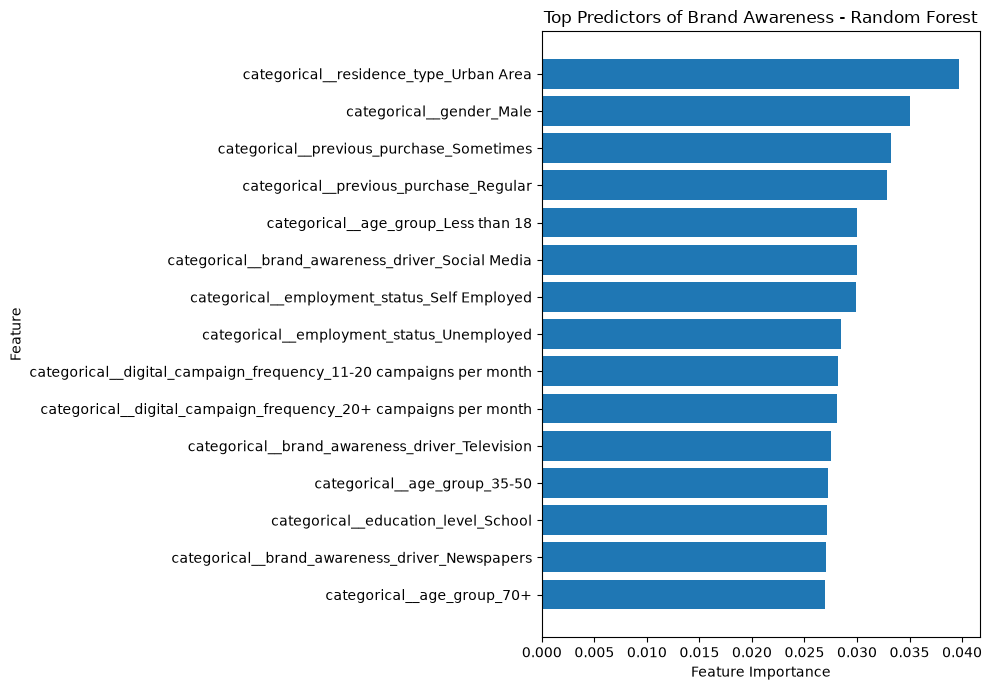

In [28]:
# ---------------------------------------------------------
# STAGE 9G: TOP FEATURE IMPORTANCE VISUALIZATION
# ---------------------------------------------------------

import matplotlib.pyplot as plt

top_features = rf_importance_table.head(15).sort_values(
    "importance"
)

plt.figure(figsize=(10, 7))

plt.barh(
    top_features["feature"],
    top_features["importance"]
)

plt.xlabel("Feature Importance")
plt.ylabel("Feature")
plt.title("Top Predictors of Brand Awareness - Random Forest")

plt.tight_layout()
plt.show()

In [29]:
# ---------------------------------------------------------
# SAVE RANDOM FOREST FEATURE IMPORTANCE
# ---------------------------------------------------------

rf_importance_path = (
    PROJECT_ROOT
    / "outputs"
    / "tables"
    / "awareness_random_forest_importance.csv"
)

rf_importance_table.to_csv(
    rf_importance_path,
    index=False
)

print("✓ Random Forest feature importance saved:")
print(rf_importance_path)

✓ Random Forest feature importance saved:
c:\Users\DIVYANSHU KASHYAP\Desktop\OUTLOOK-CUSTOMER-INTELLIGENCE\outputs\tables\awareness_random_forest_importance.csv


In [30]:
# ---------------------------------------------------------
# STAGE 9H: PERMUTATION IMPORTANCE
# ---------------------------------------------------------

from sklearn.inspection import permutation_importance

# Calculate permutation importance on unseen test data
permutation_result = permutation_importance(
    random_forest_model,
    X_test,
    y_test,
    scoring="roc_auc",
    n_repeats=10,
    random_state=42,
    n_jobs=-1
)

# Create table using ORIGINAL feature names
permutation_table = pd.DataFrame({
    "feature": X_test.columns,
    "importance_mean": permutation_result.importances_mean,
    "importance_std": permutation_result.importances_std
})

permutation_table = permutation_table.sort_values(
    "importance_mean",
    ascending=False
).reset_index(drop=True)

print("=" * 60)
print("PERMUTATION FEATURE IMPORTANCE")
print("=" * 60)

display(
    permutation_table.round(4)
)

PERMUTATION FEATURE IMPORTANCE


,feature,importance_mean,importance_std
0,employment_status,0.0056,0.0035
1,residence_type,0.0043,0.0026
2,brand_awareness_driver,0.0031,0.0042
3,digital_campaign_frequency,0.0016,0.0051
4,previous_purchase,0.0014,0.0042
5,digital_monthly_spend,0.0012,0.0040
6,gender,-0.0011,0.0020
7,age_group,-0.0013,0.0028
8,digital_purchase_frequency,-0.0018,0.0036
9,digital_ad_platform,-0.0027,0.0052


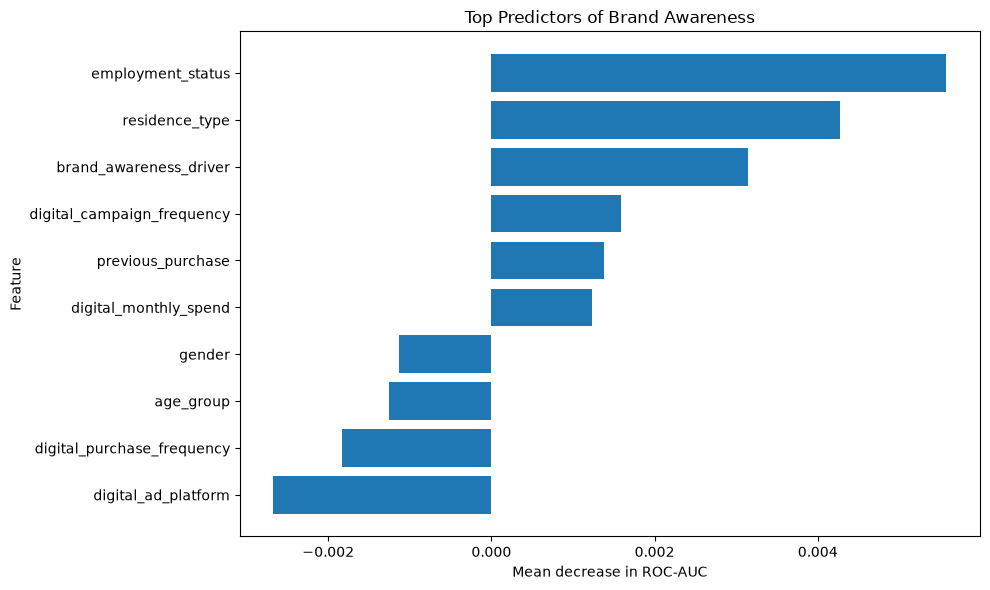

In [31]:
# ---------------------------------------------------------
# STAGE 9I: PERMUTATION IMPORTANCE VISUALIZATION
# ---------------------------------------------------------

top_permutation = (
    permutation_table
    .head(10)
    .sort_values("importance_mean")
)

plt.figure(figsize=(10, 6))

plt.barh(
    top_permutation["feature"],
    top_permutation["importance_mean"]
)

plt.xlabel("Mean decrease in ROC-AUC")
plt.ylabel("Feature")
plt.title("Top Predictors of Brand Awareness")

plt.tight_layout()
plt.show()

In [32]:
# ---------------------------------------------------------
# SAVE PERMUTATION IMPORTANCE
# ---------------------------------------------------------

permutation_path = (
    PROJECT_ROOT
    / "outputs"
    / "tables"
    / "awareness_permutation_importance.csv"
)

permutation_table.to_csv(
    permutation_path,
    index=False
)

print("✓ Permutation importance saved:")
print(permutation_path)

✓ Permutation importance saved:
c:\Users\DIVYANSHU KASHYAP\Desktop\OUTLOOK-CUSTOMER-INTELLIGENCE\outputs\tables\awareness_permutation_importance.csv


In [33]:
# ---------------------------------------------------------
# STAGE 10A: LOYALTY MODEL - LOAD DATA
# ---------------------------------------------------------

from pathlib import Path
import pandas as pd
import numpy as np

PROJECT_ROOT = Path.cwd().parent

DATA_PATH = (
    PROJECT_ROOT
    / "data"
    / "processed"
    / "cleaned_survey.csv"
)

df = pd.read_csv(DATA_PATH)

print("=" * 60)
print("LOYALTY / REPURCHASE MODEL")
print("=" * 60)

print(f"Dataset shape: {df.shape}")

print("\nRepurchase intent distribution:")
print(
    df["repurchase_intent"].value_counts()
)

print("\nRepurchase intent percentage:")
print(
    df["repurchase_intent"]
    .value_counts(normalize=True)
    .mul(100)
    .round(2)
)

LOYALTY / REPURCHASE MODEL
Dataset shape: (11109, 101)

Repurchase intent distribution:
repurchase_intent
Yes                 3773
Will think of it    3668
No                  3668
Name: count, dtype: int64

Repurchase intent percentage:
repurchase_intent
Yes                 33.96
Will think of it    33.02
No                  33.02
Name: proportion, dtype: float64


In [34]:
# ---------------------------------------------------------
# STAGE 10B: VERIFY ORDINAL TARGET
# ---------------------------------------------------------

print("Repurchase intent mapping:")
print("No               → 1")
print("Will think of it → 2")
print("Yes              → 3")

print("\nEncoded target distribution:")
print(
    df["repurchase_intent_score"]
    .value_counts()
    .sort_index()
)

print("\nEncoded target percentages:")
print(
    df["repurchase_intent_score"]
    .value_counts(normalize=True)
    .sort_index()
    .mul(100)
    .round(2)
)

# Safety check
valid_scores = {1, 2, 3}

actual_scores = set(
    df["repurchase_intent_score"].dropna().unique()
)

if not actual_scores.issubset(valid_scores):
    raise ValueError(
        f"Unexpected target values found: "
        f"{actual_scores}"
    )

print("\n✓ Ordinal target verified.")

Repurchase intent mapping:
No               → 1
Will think of it → 2
Yes              → 3

Encoded target distribution:
repurchase_intent_score
1    3668
2    3668
3    3773
Name: count, dtype: int64

Encoded target percentages:
repurchase_intent_score
1    33.02
2    33.02
3    33.96
Name: proportion, dtype: float64

✓ Ordinal target verified.


In [35]:
# ---------------------------------------------------------
# STAGE 10C: SELECT LOYALTY MODEL FEATURES
# ---------------------------------------------------------

loyalty_features = [
    "age_group",
    "gender",
    "education_level",
    "residence_type",
    "employment_status",
    "previous_purchase",
    "life_improvement_rating",
    "service_rating",
    "content_rating",
    "price_rating",
    "delivery_rating",
    "previous_experience_rating",
    "brand_solution_rating",
    "customer_support_rating",
    "overall_magazine_rating",
    "overall_experience_rating",
    "recommendation"
]

loyalty_target = "repurchase_intent_score"

loyalty_df = df[
    loyalty_features + [loyalty_target]
].copy()

print("=" * 60)
print("LOYALTY MODEL DATASET")
print("=" * 60)

print(f"Rows    : {loyalty_df.shape[0]:,}")
print(f"Columns : {loyalty_df.shape[1]}")

print("\nPredictors:")
for feature in loyalty_features:
    print(f"- {feature}")

print(f"\nTarget:")
print(f"- {loyalty_target}")

LOYALTY MODEL DATASET
Rows    : 11,109
Columns : 18

Predictors:
- age_group
- gender
- education_level
- residence_type
- employment_status
- previous_purchase
- life_improvement_rating
- service_rating
- content_rating
- price_rating
- delivery_rating
- previous_experience_rating
- brand_solution_rating
- customer_support_rating
- overall_magazine_rating
- overall_experience_rating
- recommendation

Target:
- repurchase_intent_score


In [36]:
# ---------------------------------------------------------
# STAGE 10C: MISSING-VALUE CHECK
# ---------------------------------------------------------

missing = loyalty_df.isnull().sum()

print("Missing values:")
print(missing[missing > 0])

if missing.sum() == 0:
    print("\n✓ No missing values in loyalty modeling dataset.")
else:
    print("\n⚠ Missing values found.")

Missing values:
Series([], dtype: int64)

✓ No missing values in loyalty modeling dataset.


In [37]:
# ---------------------------------------------------------
# STAGE 10D: TRAIN / TEST SPLIT
# ---------------------------------------------------------

from sklearn.model_selection import train_test_split

X_loyalty = loyalty_df[loyalty_features].copy()
y_loyalty = loyalty_df[loyalty_target].copy()

X_train_loyalty, X_test_loyalty, y_train_loyalty, y_test_loyalty = (
    train_test_split(
        X_loyalty,
        y_loyalty,
        test_size=0.20,
        random_state=42,
        stratify=y_loyalty
    )
)

print("=" * 60)
print("LOYALTY TRAIN / TEST SPLIT")
print("=" * 60)

print(f"Total observations : {len(X_loyalty):,}")
print(f"Training set       : {len(X_train_loyalty):,}")
print(f"Test set           : {len(X_test_loyalty):,}")

print("\nTraining target distribution:")
print(
    y_train_loyalty
    .value_counts()
    .sort_index()
    .to_frame("count")
    .assign(
        percentage=lambda x:
        (x["count"] / x["count"].sum() * 100).round(2)
    )
)

print("\nTest target distribution:")
print(
    y_test_loyalty
    .value_counts()
    .sort_index()
    .to_frame("count")
    .assign(
        percentage=lambda x:
        (x["count"] / x["count"].sum() * 100).round(2)
    )
)

LOYALTY TRAIN / TEST SPLIT
Total observations : 11,109
Training set       : 8,887
Test set           : 2,222

Training target distribution:
                         count  percentage
repurchase_intent_score                   
1                         2934       33.01
2                         2935       33.03
3                         3018       33.96

Test target distribution:
                         count  percentage
repurchase_intent_score                   
1                          734       33.03
2                          733       32.99
3                          755       33.98


In [38]:
# ---------------------------------------------------------
# STAGE 10E: IDENTIFY FEATURE TYPES
# ---------------------------------------------------------

numeric_loyalty_features = X_train_loyalty.select_dtypes(
    include=["int64", "float64"]
).columns.tolist()

categorical_loyalty_features = X_train_loyalty.select_dtypes(
    include=["object", "category", "bool"]
).columns.tolist()

print("=" * 60)
print("LOYALTY FEATURE TYPES")
print("=" * 60)

print("\nNumeric features:")
for col in numeric_loyalty_features:
    print(f"- {col}")

print("\nCategorical features:")
for col in categorical_loyalty_features:
    print(f"- {col}")

print("\nFeature count:")
print(f"Numeric     : {len(numeric_loyalty_features)}")
print(f"Categorical : {len(categorical_loyalty_features)}")
print(f"Total       : {len(loyalty_features)}")

LOYALTY FEATURE TYPES

Numeric features:
- life_improvement_rating
- service_rating
- content_rating
- price_rating
- delivery_rating
- previous_experience_rating
- brand_solution_rating
- customer_support_rating
- overall_magazine_rating
- overall_experience_rating
- recommendation

Categorical features:
- age_group
- gender
- education_level
- residence_type
- employment_status
- previous_purchase

Feature count:
Numeric     : 11
Categorical : 6
Total       : 17


C:\Users\DIVYANSHU KASHYAP\AppData\Local\Temp\ipykernel_26484\57194383.py:9: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  categorical_loyalty_features = X_train_loyalty.select_dtypes(


In [39]:
# ---------------------------------------------------------
# STAGE 10F: PREPROCESS LOYALTY FEATURES
# ---------------------------------------------------------

from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder

loyalty_preprocessor = ColumnTransformer(
    transformers=[
        (
            "categorical",
            OneHotEncoder(
                handle_unknown="ignore",
                drop="first"
            ),
            categorical_loyalty_features
        ),
        (
            "numeric",
            "passthrough",
            numeric_loyalty_features
        )
    ]
)

# Fit only on training data
X_train_loyalty_encoded = loyalty_preprocessor.fit_transform(
    X_train_loyalty
)

# Transform test data using the training-fitted preprocessor
X_test_loyalty_encoded = loyalty_preprocessor.transform(
    X_test_loyalty
)

# Convert sparse matrices to dense arrays
if hasattr(X_train_loyalty_encoded, "toarray"):
    X_train_loyalty_encoded = X_train_loyalty_encoded.toarray()

if hasattr(X_test_loyalty_encoded, "toarray"):
    X_test_loyalty_encoded = X_test_loyalty_encoded.toarray()

loyalty_feature_names = (
    loyalty_preprocessor
    .get_feature_names_out()
)

print("=" * 60)
print("LOYALTY PREPROCESSING")
print("=" * 60)

print(
    f"Original features  : {len(loyalty_features)}"
)

print(
    f"Encoded features   : {len(loyalty_feature_names)}"
)

print(
    f"\nTraining matrix    : "
    f"{X_train_loyalty_encoded.shape}"
)

print(
    f"Test matrix        : "
    f"{X_test_loyalty_encoded.shape}"
)

print("\n✓ Preprocessing completed.")

LOYALTY PREPROCESSING
Original features  : 17
Encoded features   : 24

Training matrix    : (8887, 24)
Test matrix        : (2222, 24)

✓ Preprocessing completed.


In [40]:
# ---------------------------------------------------------
# STAGE 10G: ORDINAL LOGISTIC REGRESSION
# ---------------------------------------------------------

from statsmodels.miscmodels.ordinal_model import OrderedModel

# Create the ordinal model
ordinal_model = OrderedModel(
    y_train_loyalty,
    X_train_loyalty_encoded,
    distr="logit"
)

# Fit the model
ordinal_result = ordinal_model.fit(
    method="bfgs",
    disp=False,
    maxiter=1000
)

print("=" * 60)
print("ORDINAL LOGISTIC REGRESSION")
print("=" * 60)

print(ordinal_result.summary())

ORDINAL LOGISTIC REGRESSION
                                OrderedModel Results                               
Dep. Variable:     repurchase_intent_score   Log-Likelihood:                -9748.7
Model:                        OrderedModel   AIC:                         1.955e+04
Method:                 Maximum Likelihood   BIC:                         1.973e+04
Date:                     Fri, 04 Sep 2026                                         
Time:                             03:41:58                                         
No. Observations:                     8887                                         
Df Residuals:                         8861                                         
Df Model:                               24                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
x1             0.0530      0.055      0.960      0.337    

In [41]:
# ---------------------------------------------------------
# STAGE 10H: ORDINAL ODDS RATIOS
# ---------------------------------------------------------

ordinal_params = ordinal_result.params

ordinal_pvalues = ordinal_result.pvalues

ordinal_conf = ordinal_result.conf_int()

ordinal_table = pd.DataFrame({
    "parameter": ordinal_params.index,
    "coefficient": ordinal_params.values,
    "p_value": ordinal_pvalues.values,
    "odds_ratio": np.exp(ordinal_params.values),
    "ci_lower": np.exp(ordinal_conf[0].values),
    "ci_upper": np.exp(ordinal_conf[1].values)
})

# Keep predictor coefficients only.
# Threshold parameters contain "/" in OrderedModel output.
predictor_mask = ~ordinal_table["parameter"].str.contains(
    "/",
    regex=False
)

ordinal_predictor_table = (
    ordinal_table[predictor_mask]
    .copy()
)

ordinal_predictor_table = ordinal_predictor_table.sort_values(
    "p_value"
)

print("=" * 60)
print("ORDINAL LOGISTIC ODDS RATIOS")
print("=" * 60)

display(
    ordinal_predictor_table.round(4)
)

ORDINAL LOGISTIC ODDS RATIOS


,parameter,coefficient,p_value,odds_ratio,ci_lower,ci_upper
14,x15,-0.0357,0.0088,0.9649,0.9395,0.9910
19,x20,-0.0320,0.0208,0.9685,0.9426,0.9952
11,x12,-0.0831,0.0835,0.9203,0.8376,1.0111
17,x18,0.0204,0.1401,1.0206,0.9933,1.0487
4,x5,0.0808,0.1451,1.0841,0.9725,1.2085
13,x14,-0.0160,0.2459,0.9842,0.9580,1.0111
6,x7,0.0634,0.2582,1.0655,0.9546,1.1892
22,x23,0.0139,0.3156,1.0140,0.9868,1.0420
0,x1,0.0530,0.3368,1.0545,0.9463,1.1750
8,x9,-0.0509,0.3546,0.9504,0.8532,1.0585


In [42]:
# ---------------------------------------------------------
# STAGE 10I: HOLM MULTIPLE-TESTING CORRECTION
# ---------------------------------------------------------

from statsmodels.stats.multitest import multipletests

p_values = ordinal_predictor_table["p_value"]

reject, corrected_p, _, _ = multipletests(
    p_values,
    alpha=0.05,
    method="holm"
)

ordinal_predictor_table["holm_p_value"] = corrected_p
ordinal_predictor_table["significant_after_holm"] = reject

# Sort by corrected p-value
ordinal_predictor_table = ordinal_predictor_table.sort_values(
    "holm_p_value"
)

print("=" * 60)
print("HOLM-CORRECTED ORDINAL LOGISTIC REGRESSION")
print("=" * 60)

display(
    ordinal_predictor_table[
        [
            "parameter",
            "coefficient",
            "odds_ratio",
            "p_value",
            "holm_p_value",
            "ci_lower",
            "ci_upper",
            "significant_after_holm"
        ]
    ].round(4)
)

HOLM-CORRECTED ORDINAL LOGISTIC REGRESSION


,parameter,coefficient,odds_ratio,p_value,holm_p_value,ci_lower,ci_upper,significant_after_holm
14,x15,-0.0357,0.9649,0.0088,0.2110,0.9395,0.9910,False
19,x20,-0.0320,0.9685,0.0208,0.4791,0.9426,0.9952,False
11,x12,-0.0831,0.9203,0.0835,1.0000,0.8376,1.0111,False
17,x18,0.0204,1.0206,0.1401,1.0000,0.9933,1.0487,False
4,x5,0.0808,1.0841,0.1451,1.0000,0.9725,1.2085,False
13,x14,-0.0160,0.9842,0.2459,1.0000,0.9580,1.0111,False
6,x7,0.0634,1.0655,0.2582,1.0000,0.9546,1.1892,False
22,x23,0.0139,1.0140,0.3156,1.0000,0.9868,1.0420,False
0,x1,0.0530,1.0545,0.3368,1.0000,0.9463,1.1750,False
8,x9,-0.0509,0.9504,0.3546,1.0000,0.8532,1.0585,False


In [43]:
# ---------------------------------------------------------
# STAGE 10J: ORDINAL MODEL TEST PREDICTIONS
# ---------------------------------------------------------

# Predict probabilities for each repurchase category
test_probabilities = ordinal_result.model.predict(
    ordinal_result.params,
    exog=X_test_loyalty_encoded
)

# Convert probabilities into the most likely class
class_values = np.array([1, 2, 3])

y_pred_loyalty = class_values[
    np.argmax(test_probabilities, axis=1)
]

print("=" * 60)
print("ORDINAL MODEL TEST PREDICTIONS")
print("=" * 60)

print("Actual classes:")
print(
    y_test_loyalty.value_counts()
    .sort_index()
)

print("\nPredicted classes:")
print(
    pd.Series(y_pred_loyalty)
    .value_counts()
    .sort_index()
)

ORDINAL MODEL TEST PREDICTIONS
Actual classes:
repurchase_intent_score
1    734
2    733
3    755
Name: count, dtype: int64

Predicted classes:
1     977
3    1245
Name: count, dtype: int64


In [44]:
# ---------------------------------------------------------
# STAGE 10K: ORDINAL PERFORMANCE METRICS
# ---------------------------------------------------------

from sklearn.metrics import (
    accuracy_score,
    mean_absolute_error,
    confusion_matrix
)

loyalty_accuracy = accuracy_score(
    y_test_loyalty,
    y_pred_loyalty
)

loyalty_mae = mean_absolute_error(
    y_test_loyalty,
    y_pred_loyalty
)

# Percentage of predictions that are either exact
# or at most one category away
within_one = (
    np.abs(
        y_test_loyalty.to_numpy() - y_pred_loyalty
    ) <= 1
).mean()

loyalty_confusion = confusion_matrix(
    y_test_loyalty,
    y_pred_loyalty,
    labels=[1, 2, 3]
)

print("=" * 60)
print("ORDINAL LOGISTIC REGRESSION PERFORMANCE")
print("=" * 60)

print(f"Exact Accuracy        : {loyalty_accuracy:.4f}")
print(f"Mean Absolute Error   : {loyalty_mae:.4f}")
print(f"Within-1 Accuracy     : {within_one:.4f}")

print("\nConfusion Matrix:")
print(loyalty_confusion)

ORDINAL LOGISTIC REGRESSION PERFORMANCE
Exact Accuracy        : 0.3294
Mean Absolute Error   : 1.0113
Within-1 Accuracy     : 0.6593

Confusion Matrix:
[[317   0 417]
 [320   0 413]
 [340   0 415]]


In [45]:
# ---------------------------------------------------------
# STAGE 10L: REPURCHASE BASELINE
# ---------------------------------------------------------

# Find the most common class in the training data
majority_class = y_train_loyalty.mode()[0]

# Predict that class for every test observation
baseline_loyalty_pred = np.full(
    len(y_test_loyalty),
    majority_class
)

baseline_loyalty_accuracy = accuracy_score(
    y_test_loyalty,
    baseline_loyalty_pred
)

baseline_loyalty_mae = mean_absolute_error(
    y_test_loyalty,
    baseline_loyalty_pred
)

baseline_loyalty_within_one = (
    np.abs(
        y_test_loyalty.to_numpy()
        - baseline_loyalty_pred
    ) <= 1
).mean()

print("=" * 60)
print("REPURCHASE BASELINE")
print("=" * 60)

print(f"Majority class       : {majority_class}")
print(f"Exact Accuracy       : {baseline_loyalty_accuracy:.4f}")
print(f"Mean Absolute Error  : {baseline_loyalty_mae:.4f}")
print(f"Within-1 Accuracy    : {baseline_loyalty_within_one:.4f}")

REPURCHASE BASELINE
Majority class       : 3
Exact Accuracy       : 0.3398
Mean Absolute Error  : 0.9905
Within-1 Accuracy    : 0.6697


In [46]:
# ---------------------------------------------------------
# STAGE 10M: ORDINAL MODEL VS BASELINE
# ---------------------------------------------------------

loyalty_model_comparison = pd.DataFrame({
    "model": [
        "Majority Class Baseline",
        "Ordinal Logistic Regression"
    ],
    "accuracy": [
        baseline_loyalty_accuracy,
        loyalty_accuracy
    ],
    "mae": [
        baseline_loyalty_mae,
        loyalty_mae
    ],
    "within_one_accuracy": [
        baseline_loyalty_within_one,
        within_one
    ]
})

print("=" * 60)
print("LOYALTY MODEL COMPARISON")
print("=" * 60)

display(
    loyalty_model_comparison.round(4)
)

LOYALTY MODEL COMPARISON


,model,accuracy,mae,within_one_accuracy
0,Majority Class Baseline,0.3398,0.9905,0.6697
1,Ordinal Logistic Regression,0.3294,1.0113,0.6593


In [47]:
# ---------------------------------------------------------
# STAGE 10N: SAVE LOYALTY MODEL RESULTS
# ---------------------------------------------------------

loyalty_results_path = (
    PROJECT_ROOT
    / "outputs"
    / "tables"
    / "loyalty_ordinal_model_results.csv"
)

loyalty_model_comparison.to_csv(
    loyalty_results_path,
    index=False
)

ordinal_results_path = (
    PROJECT_ROOT
    / "outputs"
    / "tables"
    / "loyalty_ordinal_inference.csv"
)

ordinal_predictor_table.to_csv(
    ordinal_results_path,
    index=False
)

print("✓ Loyalty model results saved:")
print(loyalty_results_path)

print("\n✓ Ordinal regression inference saved:")
print(ordinal_results_path)

✓ Loyalty model results saved:
c:\Users\DIVYANSHU KASHYAP\Desktop\OUTLOOK-CUSTOMER-INTELLIGENCE\outputs\tables\loyalty_ordinal_model_results.csv

✓ Ordinal regression inference saved:
c:\Users\DIVYANSHU KASHYAP\Desktop\OUTLOOK-CUSTOMER-INTELLIGENCE\outputs\tables\loyalty_ordinal_inference.csv
